## License

This notebook is a conversion of a Sentinel Hub evalscript and is licensed under
**CC-BY-SA-4.0**.

Original evalscript: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/oil-spill-index/

Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)

Conversion: Development Seed (openEO-UDP project)

# OSI - Oil Spill Index

This notebook demonstrates how to detect oil spill in different visualization styles.

The OSI (Oil Spill Index) uses visible Sentinel-2 bands to display oil spills over water in the costal/marine environment. The OSI is constructed by summing-up the bands representing the shoulders of absorption features of oil as numerator and the band located nearest to the absorption feature as denominator to discriminate oil spill as below.

1. In grayscale
$$\text{OSI} = \frac{(B_{03} + B_{04})}{(B_{02})}$$

2. RGB visualization
$$\text{Red} = \frac{(B_{05} + B_{06})}{(B_{07})}$$
$$\text{Green} = \frac{(B_{03} + B_{04})}{(B_{02})}$$
$$\text{Blue} = \frac{(B_{11} + B_{12})}{(B_{08})}$$

Where: 
- B02 (492.4 nm): Blue band
- B03 (559.8 nm): Green band
- B04 (664.6 nm): Red band
- B05 (704.1 nm): Vegetation red edge
- B06 (740.5 nm): Vegetation red edge
- B07 (782.8 nm): Vegetation red edge
- B08 (832.8 nm): NIR
- B11 (1613.7 nm): SWIR
- B12 (2202.4 nm): SWIR

## Overview

In this notebook, we will:
1. Connect to CDSE openEO backend service (https://openeo.dataspace.copernicus.eu/)
2. Define an area of interest containing the marine environment
3. Load Sentinel-2-L2A imagery 
4. Calculate OSI 
5. Generate an RGB visualization

## Import Required Libraries

We begin by importing the necessary Python libraries for data processing and visualization.

In [ ]:
import openeo
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
from openeo.processes import array_create, if_

## Connect to CDSE OpenEO Backend

Connect to the OpenEO backend and authenticate using OpenID Connect.

In [16]:
connection = openeo.connect(
    url="https://openeo.dataspace.copernicus.eu/"
).authenticate_oidc()

Authenticated using refresh token.


## Define Area of Interest

Define the spatial extent for our analysis. This example uses coordinates of Mauritios shore.

In [17]:
spatial_extent = {"west": 57.70, "south": -20.45, "east": 57.77, "north": -20.41}

## Load Sentinel-2 Data

Load Sentinel-2 L2A (bottom-of-atmosphere reflectance) data.

In [18]:
s2cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=spatial_extent,
    temporal_extent=["2020-07-17", "2020-09-06"], 
    bands=[
        "B02",
        "B03",
        "B04",
        "B05",
        "B06",
        "B07",
        "B08",
        "B11",
        "B12"
    ],
)

# Scale digital numbers to reflectance [0, 1]
s2cube = s2cube / 10000

# Define several timestamps for data comparison
before_oil_spill = s2cube.filter_temporal(["2020-07-17"]).reduce_dimension(dimension="t", reducer="first")
oil_spill = s2cube.filter_temporal(["2020-08-01"]).reduce_dimension(dimension="t", reducer="first")
dissolute_oil_spill = s2cube.filter_temporal(["2020-08-06"]).reduce_dimension(dimension="t", reducer="first")

# Use a wider post-spill window and take the latest available scene.
after_oil_spill = s2cube.filter_temporal(["2020-08-30", "2020-09-06"]).reduce_dimension(dimension="t", reducer="last")

## Define RGB visualization for oil spill

In [19]:
def oil_spill_viz(data):
    B02, B03, B04, B05, B06, B07, B08, B11, B12 = (
        data[0],
        data[1],
        data[2],
        data[3],
        data[4],
        data[5],
        data[6],
        data[7],
        data[8]
    )

    red = (B05 + B06) / B07
    green = (B03 + B04) / B02 # OSI
    blue = (B11 + B12) / B08

    osi_viz = array_create([red / 3, green / 3, blue / 3])

    return osi_viz

In [20]:
before_oil_spill_image = before_oil_spill.apply_dimension(dimension="bands", process=oil_spill_viz)
oil_spill_image = oil_spill.apply_dimension(dimension="bands", process=oil_spill_viz)
dissolute_oil_spill_image = dissolute_oil_spill.apply_dimension(dimension="bands", process=oil_spill_viz)
after_oil_spill_image = after_oil_spill.apply_dimension(dimension="bands", process=oil_spill_viz)

In [21]:
run_job_list = ["before_oil_spill_image", "oil_spill_image", "dissolute_oil_spill_image", "after_oil_spill_image"]

for job in run_job_list:
    output_file = Path(f"{job}.png")

    if output_file.exists():
        print(f"Skipping job (already exists): {output_file}")
        continue

    print(f"Running job: {job}")
    globals()[job] = globals()[job].linear_scale_range(0, 1, 0, 255)
    globals()[job].download(str(output_file))
    print(f"Finished: {job}")

Skipping job (already exists): before_oil_spill_image.png
Skipping job (already exists): oil_spill_image.png
Skipping job (already exists): dissolute_oil_spill_image.png
Running job: after_oil_spill_image
Finished: after_oil_spill_image


## Visualization

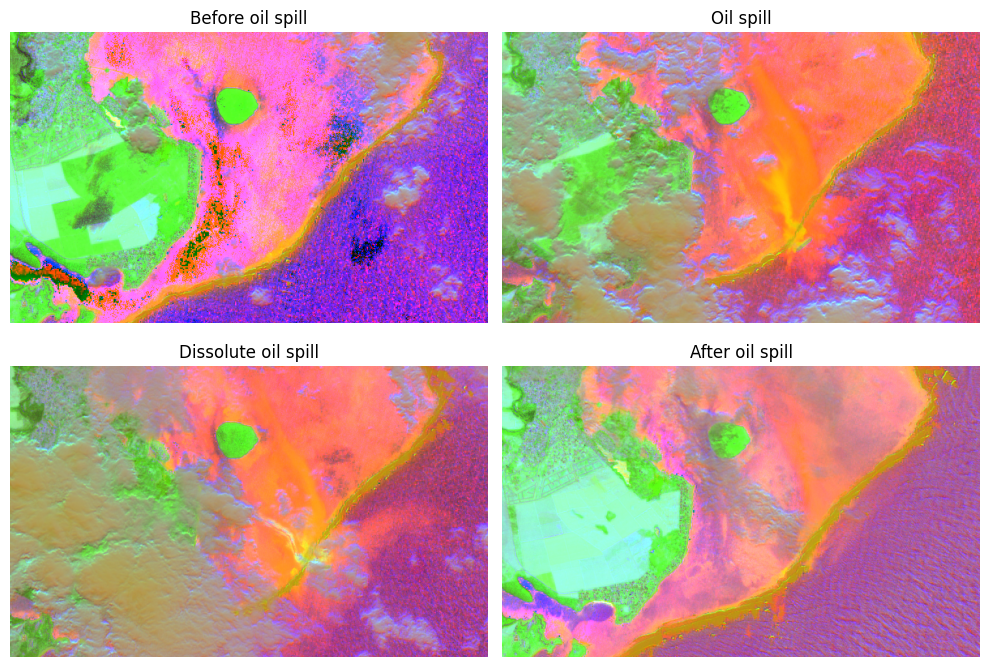

In [45]:
# Load and display the image
image_list = ["before_oil_spill_image", "oil_spill_image", "dissolute_oil_spill_image", "after_oil_spill_image"]

fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=100)
fig.subplots_adjust(hspace=-0.65, wspace=0.05)

for ax, image in zip(axes.ravel(), image_list):
    title = image.split("_")[:-1]
    title = " ".join(title).capitalize()

    img = Image.open(f"{image}.png")
    ax.imshow(img)
    ax.set_title(
        title,
        fontsize=12,
    )
    ax.axis("off")

plt.tight_layout()
plt.show()